# Example 5b — Derating fidelity comparison (pywake / dynamiks / HAWC2)

WindGym runs derating at three fidelity levels — same derating turbine, three
rungs of physics. This notebook runs the *same* 2-turbine scenario through all
three, side by side, and doubles as a cross-fidelity sanity check that they
behave consistently:

| | turbine model | backend | what this rung adds |
|---|---|---|---|
| **A — pywake** | `PowerCtNDTabular` surrogate from `data/dtu10mw_derating_yaw_surrogate.nc` (HAWCStab2, min-ct re-optimised) | py_wake steady-state (Blondel–Cathelain 2020 deficit) | steady wake interaction; instant, deterministic |
| **B — dynamiks** | same surrogate | dynamiks DWM, Mann turbulence box | wake advection + meandering transients, turbulent inflow |
| **C — HAWC2** | full aeroelastic DTU 10 MW, DTUWEC derate controller (strategy 2, avail-mode) | dynamiks + h2lib | aeroelasticity + the controller's own available-power estimate |

**Scenario** — exactly `hawc2_derating_2wt.py` (the validated PASS/FAIL script,
imported below so nothing can drift): 2× DTU 10 MW inline at 5D spacing, wind
10 m/s / TI 6% / wd 270°, Mann turbulence with seed 0,
`derate_reference="available"`, derate-only actions (`yaw_action: false`),
1 s steps.

| phase | t [s] | WT0 derate d |
|---|---|---|
| pre-derate | 0–350 | 0 |
| hold | 350–600 | 0.5 |
| recovery | 600–950 | 0 |

Metrics are means over the settled **last 150 s** of each phase — WT1's deep
wake needs ~100 s advection (5D at 10 m/s) plus ~200 s DWM settling after any
change at WT0. Those timings exist only in B and C: fidelity A solves a fresh
steady state every step, so its traces are square waves — flat lines between
the derate switches, with WT1's gain appearing in the same step the derate
lands (the wake responds instantly). A also has **no inflow realisation** at
all (`turbtype` is ignored, no Mann box, seed-invariant); B and C are both
live seed-0 Mann-box runs with identical turbulence statistics (same
generator parameters, box size, TI) — but not the same realisation: the HAWC2
backend consumes one extra RNG draw at reset (the unique results-file name
string in `_init_wts`), so B and C draw different box seeds — visible in the
`MannGenerate box seed` lines below. The sanity metrics judge each fidelity
against the script's bands rather than requiring point-wise agreement, so
this does not affect the checks.

One expectation to calibrate before reading the plots: fidelity C's hold does
**not** sit exactly at 0.5. The avail-mode DTUWEC controller holds
d × its *own* online available-power estimate (Kopt·(7.25·V/R)³ from the
estimated wind speed), which floats with the turbulent wind — so C's hold is
judged against the band `HOLD_BAND = (0.35, 0.70)` rather than a point. A and
B instead apply (1 − d) to an instantaneous table lookup; A's hold ratio is
exactly 0.50 (deterministic), B's wobbles with the turbulence.

All three fidelities run live in this notebook, fully from within windgym —
A in seconds (steady-state solves, no Mann box), B in a few minutes (Mann-box
generation at reset dominates), C in ~10–30 min (two full aeroelastic HAWC2
instances; the HAWC2 licence is checked when h2 initialises, so C needs the
DTU VPN).

## 1. Setup

Importing `hawc2_derating_2wt` gives us the scenario constants
(`CONFIG`, `T_ON/T_OFF/T_END`, `WINDOW`, `DERATE`, `HOLD_BAND`,
`RECOVERY_TOL`, `WSP/TI/SPACING_D`, `HTC_PATH`, `DATA_PATH`) and
`derate_schedule(t)` straight from the validated script. The import has two
side effects we handle explicitly: it forces the headless `Agg` matplotlib
backend (saved/restored around the import) and it prepends `sys.prefix/lib`
to `LD_LIBRARY_PATH` (the Intel Fortran runtime h2lib's spawned HAWC2
children need — wanted, and also set in this cell first so cell execution
order can never break it).

In [1]:
import os
import sys
from pathlib import Path

# The HAWC2 shared library needs the Intel Fortran runtime shipped inside the
# active environment (sys.prefix/lib); h2lib does not add it to the loader
# path. hawc2_derating_2wt sets this on import too, but set it first here so
# cell execution order can never break the h2lib spawn children.
os.environ["LD_LIBRARY_PATH"] = (
    sys.prefix + "/lib" + os.pathsep + os.environ.get("LD_LIBRARY_PATH", "")
)

import matplotlib

_backend = matplotlib.get_backend()  # the script forces Agg at import ...
import hawc2_derating_2wt as h2s

matplotlib.use(_backend, force=True)  # ... restore the notebook backend

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from py_wake.examples.data.dtu10mw import DTU10MW

from WindGym import WindFarmEnv

SURROGATE_NC = Path("data/dtu10mw_derating_yaw_surrogate.nc")
assert SURROGATE_NC.exists(), (
    f"surrogate not found: {SURROGATE_NC.resolve()} — run this notebook from "
    "the examples/ directory."
)

# one colour per fidelity, fixed order (colourblind-safe Okabe-Ito subset)
COLORS = {"A pywake": "#E69F00", "B dynamiks": "#0072B2", "C HAWC2": "#D55E00"}

print(
    f"scenario: 2x DTU 10 MW inline, {h2s.SPACING_D:g}D spacing, "
    f"{h2s.WSP:g} m/s, TI {h2s.TI:.0%}, wd 270 deg, seed 0"
)
print(
    f"phases:   WT0 at d={h2s.DERATE:g} for t in [{h2s.T_ON}, {h2s.T_OFF}) s, "
    f"episode {h2s.T_END} s, settled window {h2s.WINDOW} s"
)
print(f"checks:   HOLD_BAND={h2s.HOLD_BAND}, RECOVERY_TOL={h2s.RECOVERY_TOL}")

scenario: 2x DTU 10 MW inline, 5D spacing, 10 m/s, TI 6%, wd 270 deg, seed 0
phases:   WT0 at d=0.5 for t in [350, 600) s, episode 950 s, settled window 150 s
checks:   HOLD_BAND=(0.35, 0.7), RECOVERY_TOL=0.15


## 2. Level-0 static curves — what all three fidelities share

Before any dynamic simulation, look at the surrogate's static curves at the
scenario wind speed. This single turbine model is the derating story all
three fidelities tell: A and B use it directly as their `powerCtFunction`,
and it is the HAWCStab2 stand-in for the DTUWEC controller that fidelity C
runs live. Power holds `(1 − d) · P0` by construction; the interesting curve
is **thrust** — for every derate level, HAWCStab2 picked the pitch/TSR
combination that meets the power target with *minimum ct*, so thrust falls
much faster than power. That thrust shedding is the entire wake-control
payoff: it is why WT1 gains during the hold at every fidelity below.

(Historical note: WindGym used to ship a power-curve-inversion retrofit,
`add_derating_to_turbine`, that read the derated ct off the turbine's
*normal* operating curve at a lower equivalent wind speed. It was removed:
below rated that curve is a near-flat plateau — ct ≈ 0.82 vs the surrogate's
0.29 at d = 0.5 @ 10 m/s — so the wake barely weakened and there was no
wake-control value. Turbines must now accept `derate` natively.)

at d=0.5: P/P0 = 0.50, Ct = 0.29 (min-ct re-optimised; the removed normal-curve inversion sat at Ct ≈ 0.82 here)


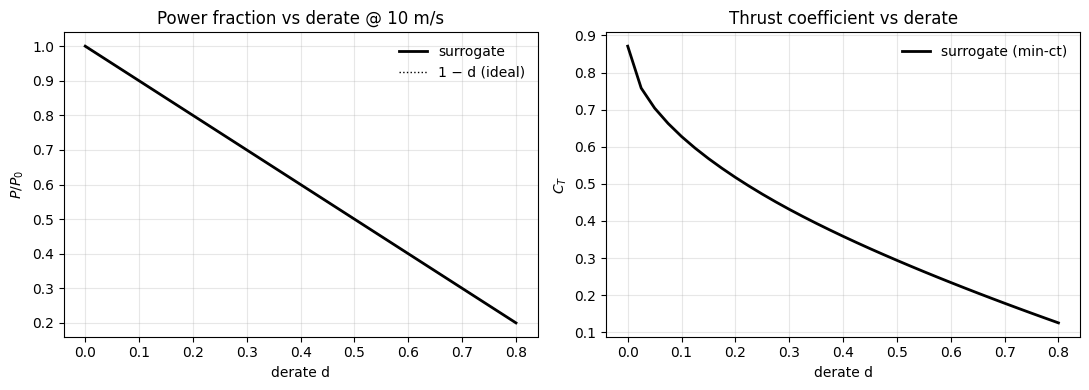

In [2]:
# --- make_derating_dtu10mw: copied verbatim from
# --- "Example 5 Derating PyWake surrogate.ipynb" (section 1) — keep in sync.
from py_wake.wind_turbines import WindTurbine
from py_wake.wind_turbines.power_ct_functions import DensityScale, PowerCtNDTabular


def make_derating_dtu10mw(nc_path=SURROGATE_NC) -> WindTurbine:
    ds = xr.load_dataset(nc_path).transpose("ws", "yaw", "derating")
    ref = DTU10MW()

    pctf = PowerCtNDTabular(
        input_keys=["ws", "yaw", "derate"],
        value_lst=[ds.ws.values, ds.yaw.values.astype(float), ds.derating.values],
        power_arr=ds.power.values,
        power_unit="W",
        ct_arr=ds.ct.values,
        default_value_dict={"yaw": 0.0, "derate": 0.0},
        additional_models=[DensityScale(1.225)],
    )
    for gi in pctf.interp:
        gi.bounds = "limit"

    return WindTurbine(
        name="DTU10MW",
        diameter=ref.diameter(),
        hub_height=ref.hub_height(),
        powerCtFunction=pctf,
    )


wt_sur = make_derating_dtu10mw()

d_sweep = np.linspace(0, 0.8, 33)
ws_arr = np.full_like(d_sweep, h2s.WSP)

P_sur = wt_sur.power(ws_arr, derate=d_sweep)
Ct_sur = wt_sur.ct(ws_arr, derate=d_sweep)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(d_sweep, P_sur / P_sur[0], color="k", lw=2, label="surrogate")
axes[0].plot(d_sweep, 1 - d_sweep, "k:", lw=1, label="1 − d (ideal)")
axes[0].set_ylabel("$P/P_0$")
axes[0].set_title(f"Power fraction vs derate @ {h2s.WSP:g} m/s")
axes[1].plot(d_sweep, Ct_sur, color="k", lw=2, label="surrogate (min-ct)")
axes[1].set_ylabel("$C_T$")
axes[1].set_title("Thrust coefficient vs derate")
for ax in axes:
    ax.set_xlabel("derate d")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)
plt.tight_layout()

i50 = int(np.argmin(np.abs(d_sweep - h2s.DERATE)))
print(
    f"at d={h2s.DERATE:g}: P/P0 = {P_sur[i50] / P_sur[0]:.2f}, "
    f"Ct = {Ct_sur[i50]:.2f} (min-ct re-optimised; the removed normal-curve "
    f"inversion sat at Ct ≈ 0.82 here)"
)

In [3]:
wt_sur = make_derating_dtu10mw()
wt_nor = DTU10MW()

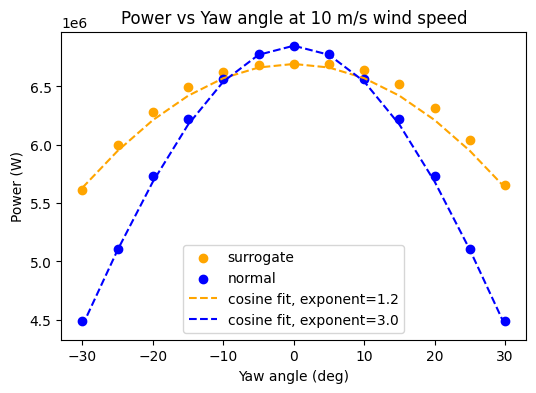

In [38]:

yaw_test = np.linspace(-30, 30, 13)  # yaw angles to test (deg)
WS = 10  # wind speed to test (m/s)
pow_sur_plot = []
pow_nor_plot = []

for yaw in yaw_test:
    power_sur = wt_sur.power(ws=WS, derate=0, yaw=yaw)
    power_nor = wt_nor.power(ws=WS, yaw=yaw)

    pow_sur_plot.append(power_sur)
    pow_nor_plot.append(power_nor)


power_sur_plot = np.array(pow_sur_plot)
power_nor_plot = np.array(pow_nor_plot)




max_power_sur = wt_sur.power(ws=WS, derate=0, yaw=0)
max_power_nor = wt_nor.power(ws=WS, yaw=0) 


sur_fit = 1.2
nor_fit = 3.0

test_sur = max_power_sur * np.cos(np.deg2rad(yaw_test))**sur_fit
test_nor = max_power_nor * np.cos(np.deg2rad(yaw_test))**nor_fit



fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(yaw_test, pow_sur_plot, color="orange", label="surrogate")
ax.scatter(yaw_test, pow_nor_plot, color="blue", label="normal")

ax.plot(yaw_test, test_sur, color="orange", linestyle="--", label=f"cosine fit, exponent={sur_fit:.1f}")
ax.plot(yaw_test, test_nor, color="blue", linestyle="--", label=f"cosine fit, exponent={nor_fit:.1f}")

ax.set_xlabel("Yaw angle (deg)")
ax.set_ylabel("Power (W)")
ax.set_title(f"Power vs Yaw angle at {WS} m/s wind speed")
ax.legend()

plt.show()

## 3. Common env factory and driving loop

The env construction mirrors the script's `run()` one-to-one — the only
degrees of freedom are the turbine object, the backend, and (for C) the htc
path. On the pywake backend `turbtype` is a harmless no-op (there is no Mann
box to generate) and each `env.step` is a full steady-state solve. The
driving loop is a copy of the script's (its `run()` hardcodes the HAWC2 env,
so it cannot be imported directly — keep the two in sync).

Unit note: `info["Power pr turbine agent"]` is always **watts** (the HAWC2
adapter normalises kW → W); the script's npz stores **MW**, so `run_env`
divides by 1e6 to keep all three fidelities in the same units.

In [3]:
def make_env(turbine, backend="dynamiks", htc_path=None):
    """The script's env, parameterised on turbine + backend (+ htc for C)."""
    return WindFarmEnv(
        turbine=turbine,
        x_pos=[0.0, h2s.SPACING_D * turbine.diameter()],
        y_pos=[0.0, 0.0],
        config=h2s.CONFIG,
        HTC_path=htc_path,
        backend=backend,
        dt_sim=1,
        dt_env=1,
        max_time_steps=h2s.T_END,
        burn_in_passthroughs=1,
        turbtype="MannGenerate",  # dynamiks only; no-op on the pywake backend
        reset_init=False,
        seed=0,
    )


def run_env(env, label, readback=False):
    """Drive the derate schedule; copied from hawc2_derating_2wt.run() — keep in sync."""
    probes = {
        h2s.T_ON - h2s.WINDOW // 2,
        h2s.T_OFF - h2s.WINDOW // 2,
        h2s.T_END - h2s.WINDOW // 2,
    }
    t_hist, power, cmd, measured = [], [], [], []
    rb_t, rb_v = [], []
    try:
        print(f">>> [{label}] reset (Mann-box generation + backend init)")
        env.reset(seed=0)
        print(f">>> [{label}] running 0-{h2s.T_END} s")
        for t in range(h2s.T_END):
            d0 = h2s.derate_schedule(t)
            # absolute derate_method maps action a in [-1, 1] affinely onto
            # [derate_min, derate_max] = [0, 1], so the inverse is a = 2 d - 1
            action = np.array([2.0 * d0 - 1.0, -1.0], dtype=np.float32)
            _, _, terminated, truncated, info = env.step(action)

            t_hist.append(t)
            power.append(np.asarray(info["Power pr turbine agent"], dtype=float))
            cmd.append(np.asarray(info["derate agent"], dtype=float))
            measured.append(np.asarray(info["derate measured"], dtype=float))
            if readback and t in probes:
                # HAWC2 only: the derate sensor re-reads "general variable 2"
                # from HAWC2 and maps it back to a fraction. (On the pywake
                # backend wts.sensors.derate stays zeros — the derate lives in
                # env.fs._derate — so readback stays a fidelity-C probe.)
                rb_t.append(t)
                rb_v.append(np.ravel(np.asarray(env.wts.sensors.derate, dtype=float)))
                print(f"    t={t:4d} s  sensor readback d = {rb_v[-1]}")
            if t % 100 == 0:
                p = power[-1] / 1e6
                print(
                    f"    t={t:4d} s  d(WT0)={d0:4.2f}  Pel [MW]: "
                    + "  ".join(f"{v:5.2f}" for v in p)
                )
            if terminated or truncated:
                break
    finally:
        env.close()

    out = {
        "t": np.asarray(t_hist),
        "power": np.asarray(power) / 1e6,  # W -> MW (matches the script's npz)
        "cmd": np.asarray(cmd),
        "measured": np.asarray(measured),
    }
    if readback:
        out["readback_t"] = np.asarray(rb_t)
        out["readback_v"] = np.asarray(rb_v)
    return out


results = {}

Run A and B live — in separate cells so each fidelity's wall time is visible
(A: seconds; B: minutes, Mann-box generation at reset dominates), and
sequentially, each env closed before the next opens (dynamiks + a Mann box
per env is memory-hungry — the pywake env is tiny).

In [4]:
results["A pywake"] = run_env(make_env(make_derating_dtu10mw(), backend="pywake"), "A")

max_time_steps=950: episode length fixed to 950 env steps (950 s of simulation); n_passthrough is ignored.
>>> [A] reset (Mann-box generation + backend init)


>>> [A] running 0-950 s
    t=   0 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


    t= 100 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


    t= 200 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


    t= 300 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


...

    t= 500 s  d(WT0)=0.50  Pel [MW]:  3.35   3.59


    t= 600 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


    t= 700 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


    t= 800 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


    t= 900 s  d(WT0)=0.00  Pel [MW]:  6.69   0.71


In [5]:
results["B dynamiks"] = run_env(make_env(make_derating_dtu10mw()), "B")

max_time_steps=950: episode length fixed to 950 env steps (950 s of simulation); n_passthrough is ignored.
>>> [B] reset (Mann-box generation + backend init)
[TurbulenceManager] MannGenerate box seed = 7524


>>> [B] running 0-950 s
    t=   0 s  d(WT0)=0.00  Pel [MW]:  6.95   7.22


    t= 100 s  d(WT0)=0.00  Pel [MW]:  7.02   1.08


    t= 200 s  d(WT0)=0.00  Pel [MW]:  6.81   1.21


    t= 300 s  d(WT0)=0.00  Pel [MW]:  6.60   0.68


...

    t= 500 s  d(WT0)=0.50  Pel [MW]:  3.29   5.51


    t= 600 s  d(WT0)=0.00  Pel [MW]:  5.70   4.19


    t= 700 s  d(WT0)=0.00  Pel [MW]:  5.59   3.22


    t= 800 s  d(WT0)=0.00  Pel [MW]:  7.43   0.64


    t= 900 s  d(WT0)=0.00  Pel [MW]:  7.36   1.44


## 4. Fidelity C — HAWC2 backend (runs live)

This cell runs HAWC2 fully from within windgym, every execution — same
scenario, same seed as the script:

- takes ~10–30 min (two full aeroelastic HAWC2 instances);
- needs a HAWC2 licence, which is checked when h2 initialises (DTU VPN);
- the shipped DTUWEC controller/servo binaries in `HawcFiles/control/` are
  Linux-only `.so` files.

Running HAWC2 from a notebook is fine: h2lib spawns its children with the
multiprocessing *spawn* start method, and under Jupyter `__main__` is the
ipykernel launcher, so the script's `if __name__ == "__main__"` guard is not
needed here. If the licence check fails (no VPN), this cell is the only one
that fails — the A/B results above are unaffected.

The run saves the npz in the script's schema (including the sensor readback
probes), so `python examples/hawc2_derating_2wt.py --replot` keeps working
against it.

In [6]:
# Fidelity C runs live — fully from within windgym (~10-30 min; HAWC2
# licence is checked when h2 initialises, i.e. needs the DTU VPN).
res_C = run_env(make_env(DTU10MW(), htc_path=h2s.HTC_PATH), "C", readback=True)
np.savez(Path("..") / h2s.DATA_PATH, **res_C)  # script schema incl. readback -> --replot keeps working
results["C HAWC2"] = res_C

max_time_steps=950: episode length fixed to 950 env steps (950 s of simulation); n_passthrough is ignored.
>>> [C] reset (Mann-box generation + backend init)


[TurbulenceManager] MannGenerate box seed = 1652


>>> [C] running 0-950 s


    t=   0 s  d(WT0)=0.00  Pel [MW]:  8.67   7.60


    t= 100 s  d(WT0)=0.00  Pel [MW]:  7.21   1.19


...

    t= 600 s  d(WT0)=0.00  Pel [MW]:  3.79   2.81


    t= 700 s  d(WT0)=0.00  Pel [MW]:  6.43   2.97


    t= 800 s  d(WT0)=0.00  Pel [MW]:  7.32   1.01


    t= 875 s  sensor readback d = [0. 0.]


    t= 900 s  d(WT0)=0.00  Pel [MW]:  8.45   0.83


## 5. Power time series — all three fidelities overlaid

Grey band = the derate hold on WT0; green tints = the settled last-150 s
windows the metrics use. All three WT0 traces should drop to roughly half
during the hold and recover after it. WT1 (bottom) responds ~100–300 s later
through the wake in B and C — but **instantly** in A, whose steady-state
solve has no transport delay: A's traces are flat square waves, and the gap
between A's step and B/C's ramp *is* the wake dynamics the higher rungs add.

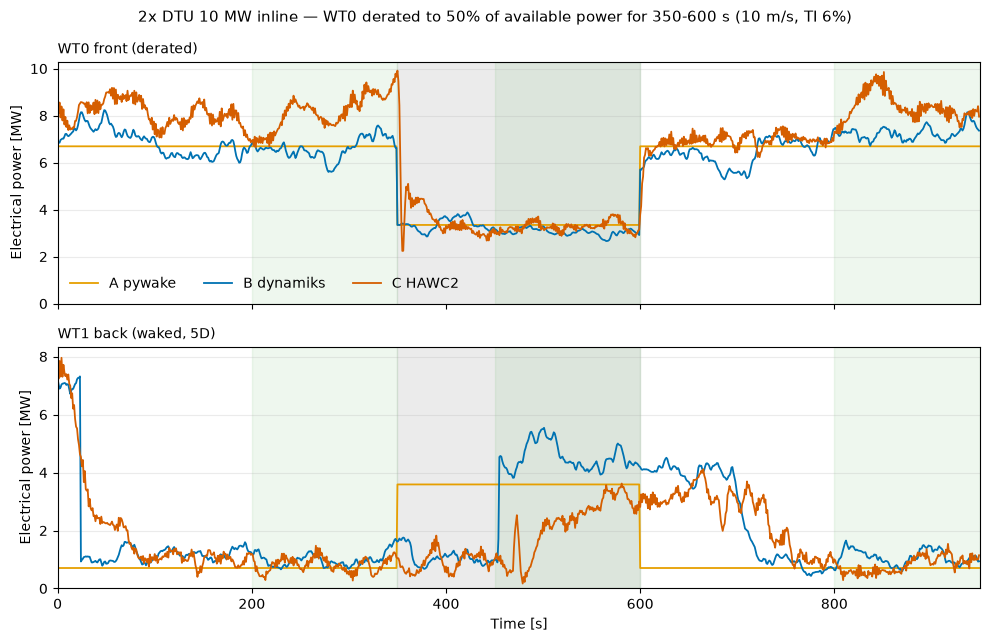

In [7]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6.5))
for label, res in results.items():
    for i, ax in enumerate(axes):
        ax.plot(res["t"], res["power"][:, i], color=COLORS[label], lw=1.3,
                label=label)
for ax, title in zip(axes, ["WT0 front (derated)", "WT1 back (waked, 5D)"]):
    ax.axvspan(h2s.T_ON, h2s.T_OFF, color="0.85", alpha=0.5, zorder=0)
    for w1 in (h2s.T_ON, h2s.T_OFF, h2s.T_END):  # settled windows
        ax.axvspan(w1 - h2s.WINDOW, w1, color="tab:green", alpha=0.08, zorder=0)
    ax.grid(axis="y", alpha=0.25)
    ax.margins(x=0)
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Electrical power [MW]")
    ax.set_title(title, fontsize=10, loc="left")
axes[0].legend(frameon=False, ncol=3)
axes[1].set_xlabel("Time [s]")
fig.suptitle(
    f"2x DTU 10 MW inline — WT0 derated to {1 - h2s.DERATE:.0%} of available "
    f"power for {h2s.T_ON}-{h2s.T_OFF} s ({h2s.WSP:g} m/s, TI {h2s.TI:.0%})",
    fontsize=11,
)
fig.tight_layout()

## 6. Settled-window comparison

Means over the settled last 150 s of each phase, reduced to the three numbers
that matter:

1. **WT0 hold ratio** — hold power over the mean of its own pre-derate and
   recovery power. Ideal 0.5; A hits it exactly (deterministic table lookup),
   B wobbles with the turbulence, C floats inside `HOLD_BAND` (grey) by
   design.
2. **WT1 gain during the hold** — the wake-control payoff. Expect it
   **positive at all three fidelities** (they share the min-ct thrust
   shedding of section 2). Absolute WT1 levels differ between A and B/C —
   different wake models (Blondel–Cathelain steady-state vs DWM) — which is
   fine; the check is qualitative consistency, not point-wise agreement.
3. **Farm total during the hold** — what the derating costs/buys net.

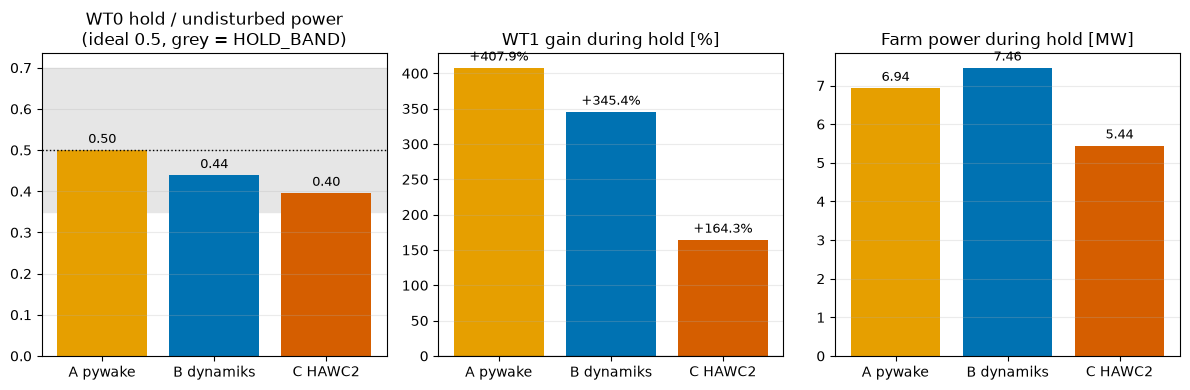

In [8]:
def settled_means(res):
    """Mean power [MW] per turbine over the settled tail of each phase."""
    t = res["t"]
    windows = {
        "pre-derate": (h2s.T_ON - h2s.WINDOW, h2s.T_ON),
        "derate hold": (h2s.T_OFF - h2s.WINDOW, h2s.T_OFF),
        "recovery": (h2s.T_END - h2s.WINDOW, h2s.T_END),
    }
    return {
        name: np.array(
            [res["power"][(t >= w0) & (t < w1), i].mean() for i in range(2)]
        )
        for name, (w0, w1) in windows.items()
    }


means = {label: settled_means(res) for label, res in results.items()}

labels = list(results)
x = np.arange(len(labels))
bar_colors = [COLORS[lab] for lab in labels]

hold_ratio = [
    means[lab]["derate hold"][0]
    / (0.5 * (means[lab]["pre-derate"][0] + means[lab]["recovery"][0]))
    for lab in labels
]
wt1_gain = [
    100
    * (means[lab]["derate hold"][1] - means[lab]["pre-derate"][1])
    / means[lab]["pre-derate"][1]
    for lab in labels
]
farm_hold = [means[lab]["derate hold"].sum() for lab in labels]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
b0 = axes[0].bar(x, hold_ratio, color=bar_colors)
axes[0].bar_label(b0, fmt="%.2f", padding=3, fontsize=9)
axes[0].axhspan(*h2s.HOLD_BAND, color="0.9", zorder=0)
axes[0].axhline(1 - h2s.DERATE, color="k", ls=":", lw=1)
axes[0].set_title("WT0 hold / undisturbed power\n(ideal 0.5, grey = HOLD_BAND)")
b1 = axes[1].bar(x, wt1_gain, color=bar_colors)
axes[1].bar_label(b1, fmt="%+.1f%%", padding=3, fontsize=9)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("WT1 gain during hold [%]")
b2 = axes[2].bar(x, farm_hold, color=bar_colors)
axes[2].bar_label(b2, fmt="%.2f", padding=3, fontsize=9)
axes[2].set_title("Farm power during hold [MW]")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

## 7. Derate command vs measured

The command square wave is shared by construction (same `derate_schedule`);
each fidelity's `"derate measured"` should track it — this verifies the
actuation plumbing (pywake farm-state derate / dynamiks turbine sensor /
HAWC2 "general variable 2" write) at every level.

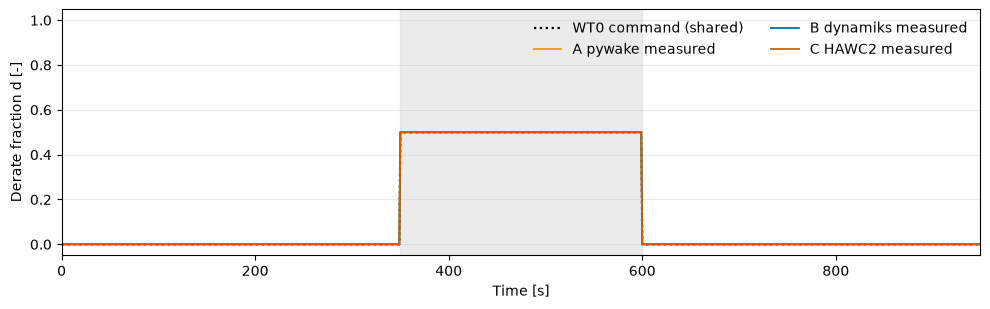

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.2))
first = next(iter(results.values()))
ax.plot(first["t"], first["cmd"][:, 0], color="k", ls=":", lw=1.6,
        label="WT0 command (shared)")
for label, res in results.items():
    ax.plot(res["t"], res["measured"][:, 0], color=COLORS[label], lw=1.3,
            label=f"{label} measured")
ax.axvspan(h2s.T_ON, h2s.T_OFF, color="0.85", alpha=0.5, zorder=0)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Derate fraction d [-]")
ax.set_ylim(-0.05, 1.05)
ax.margins(x=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()

## 8. Sanity check

The script's criteria, applied uniformly to all three fidelities:

- **hold in band** — WT0 hold ratio within `HOLD_BAND`;
- **recovery** — WT0 back to pre-derate power within `RECOVERY_TOL`;
- **measured tracks cmd** — `"derate measured"` at the commanded value
  throughout the settled hold window.

Fidelity A should pass all three trivially — hold ratio exactly 0.50 and
exact recovery, since it is a deterministic steady-state solve with no
turbulence. The WT1 gain is **REPORT-only** (in B and C it is a deep-wake
signal, noise-dominated at TI 6% — same policy as the script; expect it
positive at all three fidelities). A WARN here is informational; the hard
PASS/FAIL gate for fidelity C remains `hawc2_derating_2wt.py`.

In [10]:
rows = []
for label, res in results.items():
    m = means[label]
    pre, hold, rec = m["pre-derate"], m["derate hold"], m["recovery"]
    ratio = hold[0] / (0.5 * (pre[0] + rec[0]))
    rec_err = abs(rec[0] - pre[0]) / pre[0]
    t = res["t"]
    in_hold = (t >= h2s.T_OFF - h2s.WINDOW) & (t < h2s.T_OFF)
    tracks = np.allclose(res["measured"][in_hold, 0], h2s.DERATE, atol=0.02)
    rows.append(
        {
            "fidelity": label,
            "WT0 pre [MW]": pre[0],
            "WT0 hold [MW]": hold[0],
            "WT0 rec [MW]": rec[0],
            "WT1 pre [MW]": pre[1],
            "WT1 hold [MW]": hold[1],
            "hold ratio": ratio,
            "hold in band": "PASS"
            if h2s.HOLD_BAND[0] <= ratio <= h2s.HOLD_BAND[1]
            else "FAIL",
            "recovery": "PASS" if rec_err < h2s.RECOVERY_TOL else "FAIL",
            "measured tracks cmd": "PASS" if tracks else "FAIL",
            "WT1 gain [%] (REPORT)": 100 * (hold[1] - pre[1]) / pre[1],
        }
    )

table = pd.DataFrame(rows).set_index("fidelity").round(2)
display(table)

checks = table[["hold in band", "recovery", "measured tracks cmd"]]
print("ALL PASS" if (checks == "PASS").all().all() else "WARN — see table above")
print(
    "(WT1 gain is REPORT-only: deep-wake, noise-dominated at TI 6%. The hard "
    "PASS/FAIL gate for fidelity C remains hawc2_derating_2wt.py.)"
)

,WT0 pre [MW],WT0 hold [MW],WT0 rec [MW],WT1 pre [MW],WT1 hold [MW],hold ratio,hold in band,recovery,measured tracks cmd,WT1 gain [%] (REPORT)
fidelity,,,,,,,,,,
A pywake,6.69,3.35,6.69,0.71,3.59,0.50,PASS,PASS,PASS,407.86
B dynamiks,6.61,3.04,7.26,0.99,4.42,0.44,PASS,PASS,PASS,345.36
C HAWC2,8.16,3.27,8.36,0.82,2.18,0.40,PASS,PASS,PASS,164.29


ALL PASS
(WT1 gain is REPORT-only: deep-wake, noise-dominated at TI 6%. The hard PASS/FAIL gate for fidelity C remains hawc2_derating_2wt.py.)


## 9. Takeaways

- **One derating story, three rungs of physics.** All three fidelities share
  the same min-ct derating behaviour (section 2) and agree qualitatively:
  WT0 holds ~50% of its available power while shedding thrust hard, so WT1
  sees a weaker wake and gains during the hold. Moving up the ladder adds
  physics, not a different mechanism — A gives the steady wake interaction,
  B adds transport delay, meandering and a turbulent inflow realisation,
  C adds aeroelasticity and a real controller in the loop.
- **A (pywake) is the cheap rung.** Each step is a deterministic steady-state
  solve — milliseconds per step, no Mann box, seed-invariant — which makes it
  the natural RL-training workhorse. The price: no transients (WT1 responds
  the same step the derate lands) and, by construction, hold ratio exactly
  0.50 with exact recovery.
- **B (dynamiks) adds the dynamics that set the timing.** The ~100 s
  advection (5D at 10 m/s) plus ~200 s DWM settling are what dictate the
  settled-window design of this scenario — invisible at fidelity A.
- **C (HAWC2) is the validation rung, and floats within `HOLD_BAND` rather
  than sitting at 0.5.** The avail-mode DTUWEC controller holds d × its own
  online available-power estimate (Kopt·(7.25·V/R)³), which moves with the
  turbulent wind; A and B apply (1 − d) to an instantaneous table lookup
  instead.
- **Absolute WT1 levels differ between A and B/C** (Blondel–Cathelain
  steady-state wake vs DWM) — expected; the cross-fidelity check is
  qualitative consistency, not point-wise agreement.
- Further reading: `hawc2_derating_2wt.py` (the hard PASS/FAIL gate for the
  HAWC2 path) and `Docs/docs/derating.md` (full config semantics: available
  vs rated reference, absolute vs step actions, the HAWC2 controller
  contract).